# 📰 BBC News Popularity — Full Lab (Module 3 + Module 4)

**Scenario 09 · Cleaning + Preprocessing + Training · Binary Classification**

**Role:** Senior Machine Learning Engineer · **Status:** Module 3 & 4 completed

---

## Executive summary

We work for the content team at **BBC**. Before an article is published, the
manager (Daniel, Head of Content Strategy) wants to know one thing: *will this
article be popular and get many shares — or will it flop?* If we can predict it
**before** publishing, the team publishes smarter.

This notebook takes a **raw, messy CSV** of 39,644 articles all the way to a
**trained and honestly evaluated model**, using only facts known *before* an
article goes live.

| | |
|---|---|
| **Dataset** | `online_news_popularity.csv` (39,644 BBC articles, 2013–2015) |
| **Columns** | 61 — every column is already a number, so there is **no text cleaning** |
| **Target we build** | `is_popular` (1 = popular, 0 = not popular) |
| **Models compared** | Logistic Regression · Decision Tree · Random Forest |

**Pipeline:**
- 🧹 **Module 3 (Class 1–6):** clean the raw data → save a model-ready file.
- 🤖 **Module 4 (Class 7–9):** load the clean file → train **three** models → evaluate.


## ⚙️ Setup — data source (no Google Drive needed)

We load the dataset **directly from a public GitHub raw URL**. This means:
- No `drive.mount(...)`, no manual file upload, no folder setup.
- Anyone can run this notebook top-to-bottom in Google Colab and get identical results.


In [1]:
# The dataset is read straight from GitHub (raw text), so no Google Drive is required.
DATA_URL = "https://raw.githubusercontent.com/Davron030901/Machine_Learning/main/data/online_news_popularity.csv"

# pandas — load, clean, and manipulate tabular data
import pandas as pd
# numpy — numerical helpers (used implicitly by pandas / sklearn)
import numpy as np

# matplotlib + seaborn — visualisation (distribution plots, bar charts, confusion matrices)
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split — split data into an honest train set and a held-out test set
from sklearn.model_selection import train_test_split
# StandardScaler — put every feature on the same scale (needed for Logistic Regression)
from sklearn.preprocessing import StandardScaler

# The three classifiers we will compare:
from sklearn.linear_model import LogisticRegression      # Model 1: linear baseline
from sklearn.tree import DecisionTreeClassifier          # Model 2: single decision tree
from sklearn.ensemble import RandomForestClassifier      # Model 3: ensemble of many trees

# Metrics that together give a complete picture of classification quality
from sklearn.metrics import (
    accuracy_score,          # fraction of ALL predictions that are correct
    precision_score,         # of those predicted "popular", how many really were
    recall_score,            # of all truly popular articles, how many we caught
    f1_score,                # harmonic mean of precision and recall
    confusion_matrix,        # 2x2 table of TP / FP / TN / FN
    ConfusionMatrixDisplay,  # convenient matplotlib plot of the confusion matrix
)

import warnings
warnings.filterwarnings("ignore")  # hide non-critical convergence warnings to keep output clean

sns.set_style("whitegrid")          # apply a clean default style to all charts
print("✅ Libraries imported. Data will be read from:", DATA_URL)

✅ Libraries imported. Data will be read from: https://raw.githubusercontent.com/Davron030901/Machine_Learning/main/data/online_news_popularity.csv


---
# 🧹 MODULE 3 — Clean & Preprocess
---

## Class 1 — Load and LOOK first

**Watch out:** in this file every column name (except `url`) has a **leading space**
— for example `" shares"` instead of `"shares"`. If we forget to remove those spaces,
every `df['shares']` call later will fail with a `KeyError`. We fix it in one line.

In [2]:
# Read the raw CSV from the GitHub URL into a pandas DataFrame
df = pd.read_csv(DATA_URL)

# CRITICAL FIX: strip whitespace from EVERY column name in a single line.
# Without this, columns like " shares" keep their leading space and df['shares'] breaks.
df.columns = df.columns.str.strip()

# Confirm we loaded the full dataset with the expected dimensions
print("Shape:", df.shape)          # expected: (39644, 61)
print("First 5 columns:", df.columns[:5].tolist())

Shape: (39644, 61)
First 5 columns: ['url', 'timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens']


In [3]:
# Always LOOK at the raw data before changing anything — preview the first 5 rows
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [4]:
# describe() returns count, mean, std, min, quartiles and max for each chosen column.
# We inspect a few key columns to understand their scale before cleaning.
df[['n_tokens_content', 'num_imgs', 'num_videos', 'shares']].describe().round(2)

,n_tokens_content,num_imgs,num_videos,shares
count,39644.00,39644.00,39644.00,39644.00
mean,546.51,4.54,1.25,3395.38
std,471.11,8.31,4.11,11626.95
min,0.00,0.00,0.00,1.00
25%,246.00,1.00,0.00,946.00
50%,409.00,1.00,0.00,1400.00
75%,716.00,4.00,1.00,2800.00
max,8474.00,128.00,91.00,843300.00


## Class 2 — Find and remove broken rows

Real data has mistakes. This dataset has two problems we must fix before modelling.

In [5]:
# ── Problem 1: empty articles ───────────────────────────────────────────────
# n_tokens_content == 0 means the article body has NO words at all.
# Such rows carry zero predictive signal, so we remove them.
empty = (df['n_tokens_content'] == 0).sum()   # count how many empty articles exist
print("Empty articles (content == 0):", empty)   # expected: 1181

# Keep only rows that actually contain at least one word in the body
df = df[df['n_tokens_content'] > 0]
print("Rows after removing empty articles:", df.shape[0])

Empty articles (content == 0): 1181
Rows after removing empty articles: 38463


In [6]:
# ── Problem 2: a single corrupt value ───────────────────────────────────────
# n_non_stop_words is a ratio that must always lie between 0 and 1.
# One row has the impossible value 1042 — clearly a data-entry error.
# Left in, this one outlier would badly distort StandardScaler for ALL features.
print("Max n_non_stop_words BEFORE:", df['n_non_stop_words'].max())   # shows 1042.0 (broken)

# Drop the single physically-impossible row (ratio above 1)
df = df[df['n_non_stop_words'] <= 1]

print("Max n_non_stop_words AFTER :", df['n_non_stop_words'].max())   # shows ~1.0 (fixed)
print("Rows after full cleaning   :", df.shape[0])                    # expected: 38462

Max n_non_stop_words BEFORE: 1042.0
Max n_non_stop_words AFTER : 0.99999999978
Rows after full cleaning   : 38462


### 📊 Shares distribution — why a median split is correct

Before we build the target, we visualise `shares` to see **why** we will split at the
median and not the mean.

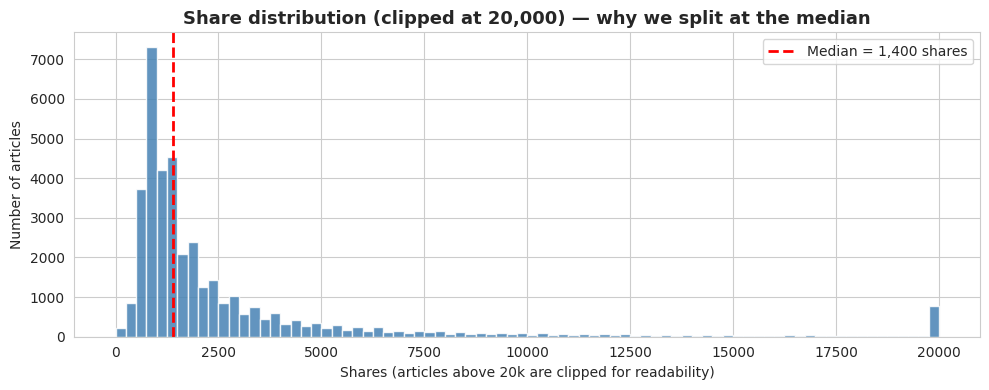

In [7]:
# The shares column is heavily right-skewed: a few viral articles (hundreds of
# thousands of shares) pull the MEAN far to the right, while the MEDIAN stays at
# the true middle of the data. This chart makes that skew visible.
fig, ax = plt.subplots(figsize=(10, 4))

# Clip the x-axis at 20,000 shares so extreme outliers don't squash the histogram
ax.hist(df['shares'].clip(upper=20000), bins=80, color='steelblue', edgecolor='white', alpha=0.85)

# Draw a red dashed line exactly at the median to mark our future split point
median_preview = df['shares'].median()
ax.axvline(median_preview, color='red', linestyle='--', linewidth=2,
           label=f"Median = {int(median_preview):,} shares")

ax.set_title("Share distribution (clipped at 20,000) — why we split at the median",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Shares (articles above 20k are clipped for readability)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

## Class 3 — Drop columns that are NOT features

Two columns must go before modelling because they describe **data collection**, not the
article itself.

In [8]:
# 'url'       -> plain text (a hyperlink); a model cannot use raw text here.
# 'timedelta' -> how many days ago the article was collected. This is about data
#                gathering, NOT about the article's quality, so it is non-predictive
#                and could even leak time-based information into the model.
df = df.drop(columns=['url', 'timedelta'])

print("Columns after dropping url & timedelta:", df.shape[1])   # expected: 59

Columns after dropping url & timedelta: 59


## Class 4 — Understand the section (channel) columns

Mashable groups articles into sections. Instead of one text column, the data uses
**six yes/no columns** — this is one-hot encoding, and it has already been done for us.

data_channel_is_lifestyle        2077.0
data_channel_is_socmed           2311.0
data_channel_is_bus              6235.0
data_channel_is_entertainment    6855.0
data_channel_is_tech             7325.0
data_channel_is_world            8168.0


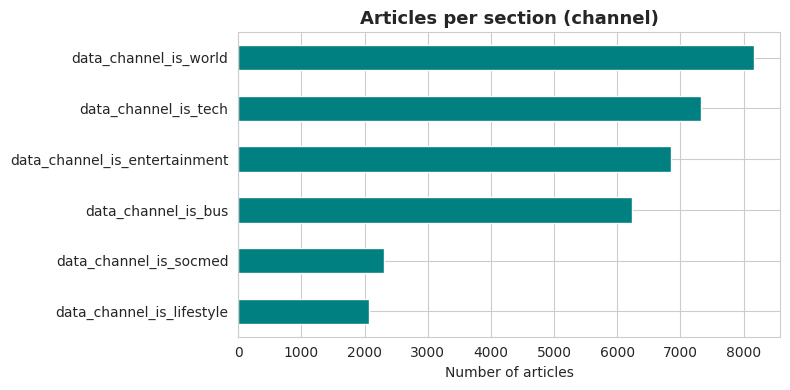

In [9]:
# Each channel column is a binary flag (0/1) for one Mashable section.
channel_cols = [
    'data_channel_is_lifestyle',      # Lifestyle articles
    'data_channel_is_entertainment',  # Entertainment news
    'data_channel_is_bus',            # Business articles
    'data_channel_is_socmed',         # Social-media topics
    'data_channel_is_tech',           # Technology articles
    'data_channel_is_world',          # World / international news
]

# Sum each column to count how many articles belong to each section.
# Note: ~15% of articles are 0 in ALL six columns (no section tag) — that is fine;
# the model simply reads "all zeros" as "no known section".
channel_counts = df[channel_cols].sum().sort_values()
print(channel_counts.to_string())

# Visualise the section sizes as a horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))
channel_counts.plot.barh(ax=ax, color='teal', edgecolor='white')
ax.set_title("Articles per section (channel)", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of articles")
plt.tight_layout()
plt.show()

## Class 5 — Build the target (the yes/no label)

The dataset gives us `shares` (a raw number). We turn it into a simple **yes/no** label.
We split at the **median** so the two groups are about equal in size.

In [10]:
# Find the median number of shares — the true middle value of the sorted list.
median_shares = df['shares'].median()
print("Median shares:", median_shares)          # expected: 1400.0

# Articles with shares >= median are labelled 1 (popular); below the median = 0 (not popular).
# WHY THE MEDIAN, not the mean? A few viral articles (hundreds of thousands of shares)
# would drag the mean upward and label almost everything "not popular". The median is
# the fair midpoint and gives us balanced ~50/50 classes.
df['is_popular'] = (df['shares'] >= median_shares).astype(int)

# Confirm the two classes are roughly balanced
print(df['is_popular'].value_counts().to_string())   # ~20,463 popular vs ~17,999 not popular

Median shares: 1400.0
is_popular
1    20463
0    17999


## Class 6 — Select final columns and SAVE (Module 3 deliverable)

We keep exactly **18 pre-publish features** plus the target. We deliberately drop
`shares` so nobody accidentally trains on it — `is_popular` was built from `shares`,
so using it would be **data leakage** (cheating).

In [11]:
# The 18 features below are all facts known BEFORE an article is published.
feature_columns = [
    'n_tokens_title',                # number of words in the title
    'n_tokens_content',              # number of words in the article body
    'num_hrefs',                     # total hyperlinks in the article
    'num_self_hrefs',                # links pointing back to Mashable
    'num_imgs',                      # number of images
    'num_videos',                    # number of videos
    'num_keywords',                  # number of keywords / tags
    'data_channel_is_lifestyle',     # section flag: Lifestyle
    'data_channel_is_entertainment', # section flag: Entertainment
    'data_channel_is_bus',           # section flag: Business
    'data_channel_is_socmed',        # section flag: Social media
    'data_channel_is_tech',          # section flag: Tech
    'data_channel_is_world',         # section flag: World news
    'is_weekend',                    # published on Saturday/Sunday? (0/1)
    'global_subjectivity',           # how opinion-based the full text is (0–1)
    'global_sentiment_polarity',     # overall positive/negative tone (-1 to +1)
    'title_subjectivity',            # how subjective the title is (0–1)
    'title_sentiment_polarity',      # positive/negative tone of the title (-1 to +1)
]

# Build the final clean table: the 18 features + the target only (shares is dropped).
final_df = df[feature_columns + ['is_popular']].copy()

# Insert a simple sequential id at column 0 so every row stays traceable.
final_df.insert(0, 'article_id', range(len(final_df)))

print("Final shape:", final_df.shape)   # expected: (38462, 20) = id + 18 features + target
final_df.head()

Final shape: (38462, 20)


,article_id,n_tokens_title,n_tokens_content,num_hrefs,num_self_hrefs,num_imgs,num_videos,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,is_weekend,global_subjectivity,global_sentiment_polarity,title_subjectivity,title_sentiment_polarity,is_popular
0,0,12.0,219.0,4.0,2.0,1.0,0.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.521617,0.092562,0.500000,-0.187500,0
1,1,9.0,255.0,3.0,1.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.341246,0.148948,0.000000,0.000000,0
2,2,9.0,211.0,3.0,1.0,1.0,0.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.702222,0.323333,0.000000,0.000000,1
3,3,9.0,531.0,9.0,0.0,1.0,0.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.429850,0.100705,0.000000,0.000000,0
4,4,13.0,1072.0,19.0,19.0,20.0,0.0,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.513502,0.281003,0.454545,0.136364,0


In [12]:
# Save the clean dataset as PARQUET — a typed, compressed columnar format.
# Parquet is preferred over CSV because it (1) preserves int/float dtypes on reload,
# (2) is several times smaller, and (3) loads faster than re-parsing a CSV.
#
# We save to the local working directory (in Colab this is /content/), NOT Google Drive.
# In Colab the file appears in the left-hand file panel and can be downloaded from there.
CLEAN_PATH = "mashable_clean.parquet"
final_df.to_parquet(CLEAN_PATH)

print("✅ MODULE 3 COMPLETE — clean file saved to:", CLEAN_PATH)
print(f"   Rows: {final_df.shape[0]:,} | Columns: {final_df.shape[1]} (article_id + 18 features + is_popular)")

✅ MODULE 3 COMPLETE — clean file saved to: mashable_clean.parquet
   Rows: 38,462 | Columns: 20 (article_id + 18 features + is_popular)


---
# 🤖 MODULE 4 — Train & Evaluate
---

## Class 7 — Load the clean file and split

We reload from the saved Parquet file. This proves Module 3 → Module 4 is a clean
hand-off with no leftover state from the cleaning steps above.

In [13]:
# Reload the clean dataset we just saved (proves the hand-off works end-to-end)
df_clean = pd.read_parquet("mashable_clean.parquet")
print("Loaded shape:", df_clean.shape)
df_clean.head()

Loaded shape: (38462, 20)


,article_id,n_tokens_title,n_tokens_content,num_hrefs,num_self_hrefs,num_imgs,num_videos,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,is_weekend,global_subjectivity,global_sentiment_polarity,title_subjectivity,title_sentiment_polarity,is_popular
0,0,12.0,219.0,4.0,2.0,1.0,0.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.521617,0.092562,0.500000,-0.187500,0
1,1,9.0,255.0,3.0,1.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.341246,0.148948,0.000000,0.000000,0
2,2,9.0,211.0,3.0,1.0,1.0,0.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.702222,0.323333,0.000000,0.000000,1
3,3,9.0,531.0,9.0,0.0,1.0,0.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.429850,0.100705,0.000000,0.000000,0
4,4,13.0,1072.0,19.0,19.0,20.0,0.0,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.513502,0.281003,0.454545,0.136364,0


In [14]:
# Separate the inputs (X) from the thing we want to predict (y).
X = df_clean[feature_columns]   # 18-column feature matrix — the model's inputs
y = df_clean['is_popular']      # 1D target vector — the answer we want to predict

# Split into 80% train / 20% test.
#   test_size=0.2   -> hold back 20% of rows for an honest final evaluation
#   random_state=42 -> fixed seed so the split is identical on every run
#   stratify=y      -> keep the same popular/not-popular ratio in BOTH halves
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train samples: {len(X_train):,}")
print(f"Test  samples: {len(X_test):,}")

# IMPORTANT: we NEVER add 'shares' back as a feature. is_popular was built from it,
# so using shares would let the model already know the answer — that is data leakage.

Train samples: 30,769
Test  samples: 7,693


## Class 8 — Scale, then train THREE models

We compare three approaches: a **linear** model (Logistic Regression) and two
**tree-based** models (a single Decision Tree and a Random Forest ensemble).

In [15]:
# StandardScaler converts each feature to a z-score: (value - mean) / std.
# This centres every feature at 0 with std 1, which Logistic Regression needs so that
# no single large-valued feature dominates its gradient-based optimisation.
#
# GOLDEN RULE: fit the scaler on the TRAIN set only. Fitting on the full dataset would
# let test-set statistics leak into training and produce dishonestly high scores.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # learn mean & std from train, then transform train
X_test_sc  = scaler.transform(X_test)        # apply the SAME learned scale to the test set
print("✅ Scaling done (fitted on train only).")

✅ Scaling done (fitted on train only).


In [16]:
# ── Model 1: Logistic Regression (linear baseline) ──────────────────────────
# Simple, fast and interpretable. It optimises a gradient-based loss, so it needs the
# SCALED features. max_iter=1000 gives it enough iterations to converge on this data.
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_sc, y_train)   # train on SCALED training data
print("✅ Logistic Regression trained.")

✅ Logistic Regression trained.


In [17]:
# ── Model 2: Decision Tree (single tree) ────────────────────────────────────
# A tree splits the data on raw thresholds, so scaling has no effect — we train on RAW X.
# We cap the depth at 10 (max_depth=10): an unconstrained tree would memorise the training
# data (overfit) and score poorly on the test set. Limiting depth keeps it general.
# This single tree also motivates Model 3: a forest of many trees is usually more accurate.
model_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
model_dt.fit(X_train, y_train)   # train on RAW (unscaled) training data
print("✅ Decision Tree trained (max_depth=10).")

✅ Decision Tree trained (max_depth=10).


In [18]:
# ── Model 3: Random Forest (ensemble of trees) ──────────────────────────────
# 100 decision trees each vote, and the majority class wins. Averaging many trees
# reduces the overfitting that a single tree suffers from. Tree-based, so we use RAW X.
# n_estimators=100 is a good accuracy/speed balance for ~38k rows.
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)   # train on RAW (unscaled) training data
print("✅ Random Forest trained (100 trees).")

✅ Random Forest trained (100 trees).


## Class 9 — Evaluate (the most important step)

We score all three models on the **held-out test set** they have never seen.

**Don't panic if accuracy is only ~65%.** Predicting virality is genuinely hard — even
Mashable's own editors cannot do it perfectly. Beating a coin flip (50%) on real human
behaviour is a real, useful result, not a failure.

In [19]:
# Evaluate every model with the same four metrics and collect the scores for charts below.
#   Accuracy  -> % of all predictions correct (meaningful here because classes are ~50/50)
#   Precision -> of articles predicted "popular", what fraction truly were (avoids wasted promotion)
#   Recall    -> of all truly popular articles, what fraction we caught (avoids missing viral hits)
#   F1        -> harmonic mean of precision and recall (punishes being good at only one)

# Each model is paired with the feature version it was trained on:
#   Logistic Regression -> SCALED test set
#   Decision Tree / Random Forest -> RAW test set
models_to_eval = [
    ("Logistic Regression", model_lr, X_test_sc),
    ("Decision Tree",       model_dt, X_test),
    ("Random Forest",       model_rf, X_test),
]

results = {}   # store every score so we can plot a comparison chart later
for name, model, X_eval in models_to_eval:
    y_pred = model.predict(X_eval)   # predict the class for each test article
    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
    }
    print(f"\n=== {name} ===")
    for metric, value in results[name].items():
        print(f"  {metric:9s}: {value:.3f}")


=== Logistic Regression ===
  Accuracy : 0.633
  Precision: 0.642
  Recall   : 0.703
  F1       : 0.671

=== Decision Tree ===
  Accuracy : 0.629
  Precision: 0.647
  Recall   : 0.668
  F1       : 0.657

=== Random Forest ===
  Accuracy : 0.638
  Precision: 0.652
  Recall   : 0.688
  F1       : 0.669


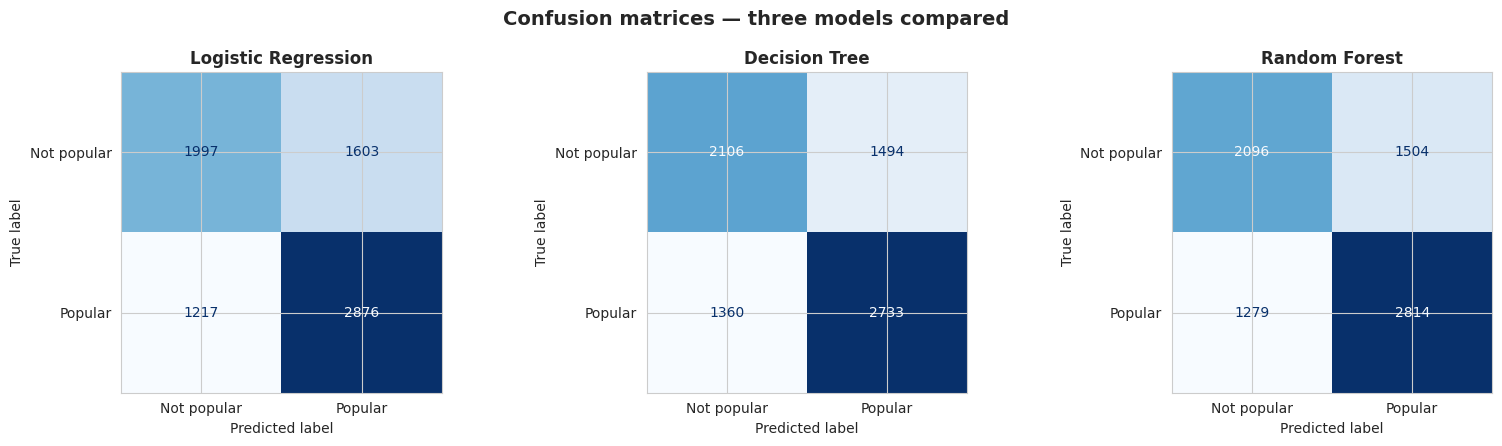

In [20]:
# Side-by-side confusion matrices let us SEE the type of mistakes each model makes.
# Reading a matrix:
#   top-left  = True Negative  (correctly called "not popular")
#   top-right = False Positive (wrongly called "popular" — it flopped)
#   bot-left  = False Negative (missed a viral article)
#   bot-right = True Positive  (correctly called "popular")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, model, X_eval) in zip(axes, models_to_eval):
    y_pred = model.predict(X_eval)               # predictions for this model
    cm = confusion_matrix(y_test, y_pred)        # build its 2x2 confusion matrix
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Not popular', 'Popular'],
    ).plot(ax=ax, colorbar=False, cmap='Blues')  # draw it on this subplot
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle("Confusion matrices — three models compared", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

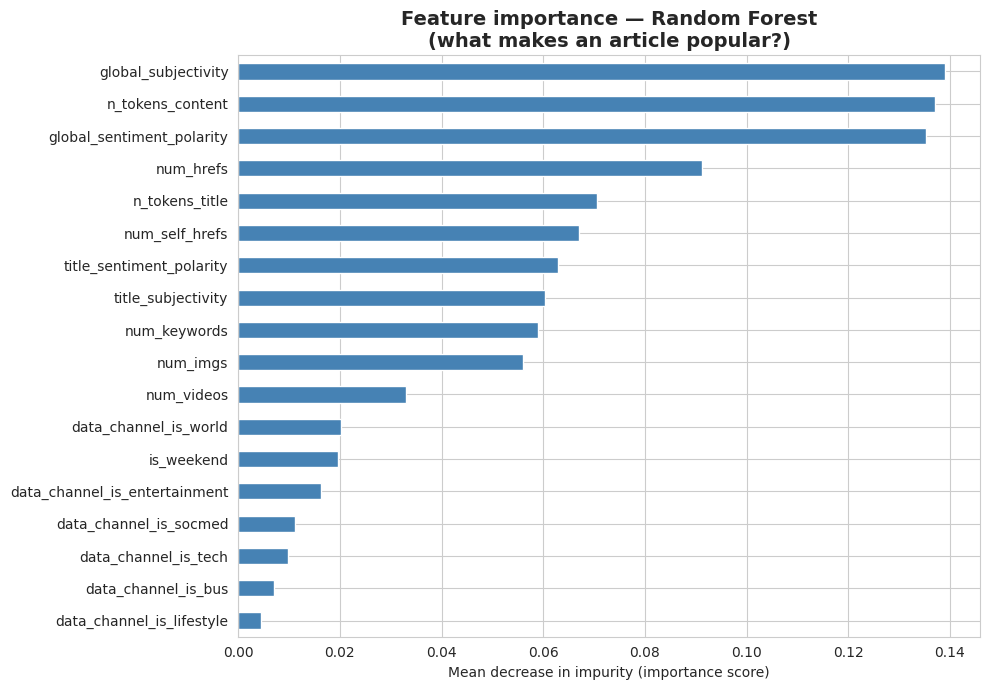

Top 8 most important features:
global_subjectivity          0.1390
n_tokens_content             0.1370
global_sentiment_polarity    0.1354
num_hrefs                    0.0913
n_tokens_title               0.0705
num_self_hrefs               0.0670
title_sentiment_polarity     0.0630
title_subjectivity           0.0604


In [21]:
# Which features matter most? Random Forest exposes feature_importances_:
# the average reduction in impurity each feature provides across all 100 trees.
# Higher = the feature separates popular vs not-popular more cleanly.
importance = pd.Series(model_rf.feature_importances_, index=feature_columns)
importance_sorted = importance.sort_values()   # ascending so the biggest bar is on top

fig, ax = plt.subplots(figsize=(10, 7))
importance_sorted.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Feature importance — Random Forest\n(what makes an article popular?)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Mean decrease in impurity (importance score)")
plt.tight_layout()
plt.show()

# Print the eight strongest features as a quick reference
print("Top 8 most important features:")
print(importance.sort_values(ascending=False).head(8).round(4).to_string())

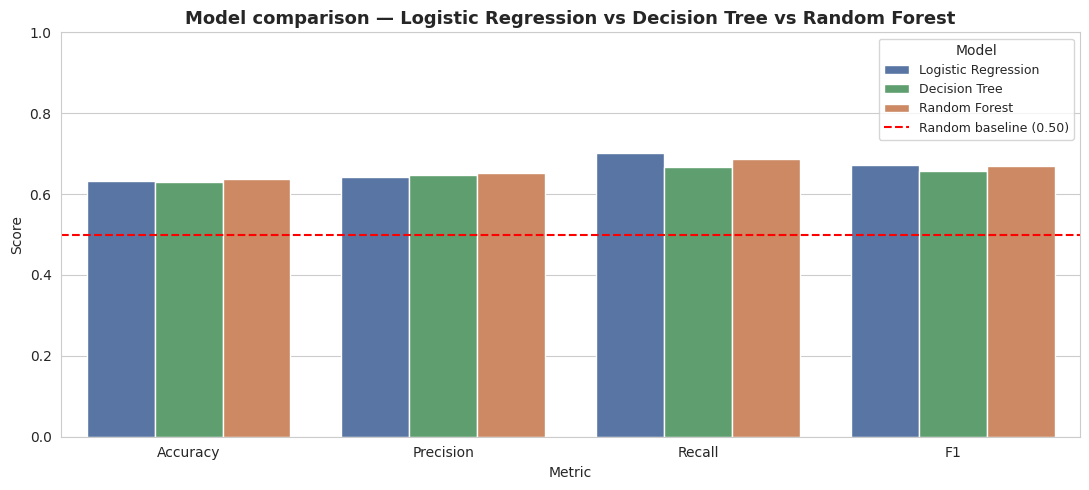

In [22]:
# Grouped bar chart: compare all four metrics across the three models at a glance.
# The red dashed line marks the 0.50 coin-flip baseline — every model should beat it.
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
results_melted = results_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',   # holds the metric name
    value_name='Score',  # holds the float score
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model',
            palette=['#4C72B0', '#55A868', '#DD8452'], ax=ax)   # blue / green / orange
ax.axhline(0.50, color='red', linestyle='--', linewidth=1.5, label='Random baseline (0.50)')
ax.set_ylim(0, 1)
ax.set_title("Model comparison — Logistic Regression vs Decision Tree vs Random Forest",
             fontsize=13, fontweight='bold')
ax.legend(title='Model', fontsize=9)
plt.tight_layout()
plt.show()

In [23]:
# Pick the winner objectively, by highest F1 (a single number that balances
# precision and recall — useful when both kinds of mistake matter).
best_model_name = max(results, key=lambda n: results[n]['F1'])

print("F1 score by model:")
for name in results:
    print(f"  {name:20s}: {results[name]['F1']:.4f}")

print(f"\n--- Final decision ---")
print(f"Best model by F1: {best_model_name}")
print("Note: scores are close, so the final choice should also reflect the business goal")
print("below — for Mashable, RECALL (catching viral articles) is arguably most important.")

F1 score by model:
  Logistic Regression : 0.6710
  Decision Tree       : 0.6570
  Random Forest       : 0.6691

--- Final decision ---
Best model by F1: Logistic Regression
Note: scores are close, so the final choice should also reflect the business goal
below — for Mashable, RECALL (catching viral articles) is arguably most important.


## ✍️ Answer these 3 questions

**1. Accuracy is around 65% — much lower than other labs. Why is predicting popularity genuinely hard, even with good data?**

Virality depends heavily on factors that are simply **not in this table**: the news
context of the day, what is trending on social media, timing relative to competing
stories, and plain luck. Two near-identical articles can perform very differently. Our
18 features describe the article's *form* (length, images, section, tone) but not the
*world it lands in*. So ~65% is an **honest score** for a hard, human-behaviour problem
— clearly above the 50% coin-flip baseline, which means the model really is learning
useful signal.

**2. Looking at the feature-importance chart, does the section (tech, world, entertainment…) matter more, or the day of week (`is_weekend`)? Why?**

The strongest features are the **content descriptors** — especially
`global_subjectivity`, `n_tokens_content` (article length) and the link/keyword counts —
rather than either the section flags or `is_weekend`. In other words, **how** an article
is written matters more than **which section** it sits in or **when** it is published.
Each individual section flag and `is_weekend` is a single 0/1 column, so it can only
split the data once; the richer numeric features carry far more information.

**3. For Mashable, which mistake is worse — predicting "popular" for an article that flops, or predicting "not popular" for an article that goes viral? Precision or recall?**

Missing a genuine viral hit (a **false negative**) is the costlier mistake: the team
fails to promote an article that would have earned large traffic and ad revenue. Wrongly
backing an article that flops (a **false positive**) mostly wastes some promotion effort.
Because the expensive error is the missed hit, Daniel should watch **recall** most
closely — and among our models the one with the highest recall is the safer pick for
that goal, even when overall accuracy is similar.
